# Agent Graph Explorer

이 노트북은 `2.agentic-ai-project`의 LangGraph 라우팅 에이전트를 단계적으로 탐색하기 위한 학습용 도구입니다.

**구성**
1. 경로 설정 & 환경 점검
2. 단일 노드 테스트(router_node, sql_node, mcp_sql_node, rag_node, web_search_node, synthesise_node, update_history_node)
3. Agent 그래프 빌드
4. 그래프 시각화 (인라인 PNG)
5. Session 생성
6. 데모 질의 (SQL / Web Search / RAG)
7. 내부 상태 관찰 (route, route_reason, tool result)
8. 자유 질의
9.  대화 이력 확인 / 초기화

**사전 준비**
- `python setup.py` 로 SQLite DB(`data/ecommerce.db`)와 FAISS 인덱스(`data/faiss_index/`)를 빌드해 두어야 합니다.
- 프로젝트 루트의 `.env` 파일에 `ANTHROPIC_API_KEY`, `SERPER_API_KEY`가 설정되어 있어야 합니다.

### Step 1 — 경로 설정 & 환경 점검

노트북은 `notebooks/` 하위에서 실행되므로, 프로젝트 루트를 `sys.path`에 추가하고 작업 디렉토리를 루트로 옮겨야 `agent.*`, `session`, `config` 등을 import 할 수 있고 `config.py`의 상대 경로(`data/`, `pdf_docs/`)도 일치합니다.

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CWD        :", os.getcwd())

PROJECT_ROOT: /Users/kmyu/Desktop/project/langchain-study/medium/2.agentic-ai-project
CWD        : /Users/kmyu/Desktop/project/langchain-study/medium/2.agentic-ai-project


In [2]:
# API 키 / 데이터 아티팩트 존재 확인 (누락 시 경고만 출력 — 노트북 커널은 중단하지 않음)
from config import (
    ANTHROPIC_API_KEY,
    OPENAI_API_KEY,
    SERPER_API_KEY,
    DB_PATH,
    FAISS_INDEX_DIR,
)

issues = []
if not (ANTHROPIC_API_KEY or OPENAI_API_KEY):
    issues.append("환경 변수 ANTHROPIC_API_KEY (또는 OPENAI_API_KEY) 가 비어 있습니다.")
if not SERPER_API_KEY:
    issues.append("환경 변수 SERPER_API_KEY 가 비어 있습니다.")
if not os.path.exists(DB_PATH):
    issues.append(f"SQLite DB 가 없습니다: {DB_PATH}  →  `python setup.py` 실행 필요")
if not os.path.exists(os.path.join(FAISS_INDEX_DIR, "index.faiss")):
    issues.append(f"FAISS 인덱스가 없습니다: {FAISS_INDEX_DIR}/index.faiss  →  `python setup.py` 실행 필요")

if issues:
    print("[WARN] 다음 항목을 확인해 주세요:")
    for line in issues:
        print("  -", line)
else:
    print("[OK] API 키와 데이터 아티팩트가 모두 준비되었습니다.")

[OK] API 키와 데이터 아티팩트가 모두 준비되었습니다.


### ⚠️ 사전 준비 — MLflow 트래킹 서버

아래 셀(`init_observability()`)은 내부적으로 `mlflow.set_tracking_uri(...)` 와 `mlflow.set_experiment(...)` 를 호출합니다. `set_experiment`은 트래킹 서버에 **실제 HTTP 요청을 보내** 실험을 조회/생성하므로, 서버가 떠 있지 않으면 `ConnectionRefusedError` 가 발생하고 urllib3 재시도 루프에서 셀이 멈춥니다.

`.env` 의 기본값은 `MLFLOW_TRACKING_URI=http://localhost:5001` 입니다 (macOS의 AirPlay Receiver가 5000번 포트를 점유하기 때문에 5001 사용).

**선택지 3가지**

1. **MLflow 서버 실행 (권장)** — 별도 터미널에서:
   ```bash
   uv run mlflow server --host 0.0.0.0 --port 5001
   # uv 미사용이면: mlflow server --host 0.0.0.0 --port 5001
   ```
   서버가 뜬 뒤 아래 셀을 실행하고, UI는 http://localhost:5001 에서 확인합니다. `@trace` 결과를 시각화하는 것이 이 모듈의 핵심이므로 학습 목적이라면 이 방법을 권장합니다.

2. **Observability 비활성화** — 트레이싱이 필요 없다면 `.env` 에 다음을 추가:
   ```
   MLFLOW_ENABLED=false
   ```
   `observability.py` 의 `ENABLED` 플래그가 `False` 가 되어 `init()` 과 `@trace` 데코레이터가 모두 패스스루로 동작합니다.

3. **서버 없이 로컬 파일/SQLite 백엔드** — 서버를 띄우지 않고 로컬에 기록만 남기고 싶다면 `.env` 의 URI를 변경:
   ```
   MLFLOW_TRACKING_URI=file:./mlruns
   # 또는
   MLFLOW_TRACKING_URI=sqlite:///mlflow.db
   ```
   나중에 UI가 필요해지면 `mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5001` 로 열 수 있습니다.

In [3]:
# 관측성(Observability) 초기화 — 선택 사항. MLflow tracing 등이 활성화됩니다.
from observability import init as init_observability

init_observability()

### Step 2 — 단일 노드 테스트 (개별 노드 호출)

그래프를 빌드·실행하기 전에 각 노드(`router_node` / `sql_node` / `mcp_sql_node` / `rag_node` / `web_search_node` / `synthesise_node` / `update_history_node`)를 **격리해서** 호출합니다. 각 노드의 입출력 계약(어떤 키를 읽고 어떤 키를 쓰는지)을 학습하고, happy-path 외에 엣지/멀티턴/에러 시나리오에서 어떻게 동작하는지 확인합니다.

| Node | 읽는 키 | 반환하는 키 | 부수 효과 | 비용 |
|------|---------|-------------|-----------|------|
| `router_node` | `user_message`, `conversation_history` | `route`, `route_reason` | Anthropic LLM 1회 | High |
| `sql_node` | `user_message`, `conversation_history` | `sql_result` | LLM + SQLite | High |
| `mcp_sql_node` | `user_message`, `conversation_history` | `mcp_sql_result` | LLM 멀티턴 + MCP 서브프로세스 + asyncio | Very High |
| `rag_node` | `user_message`, `conversation_history` | `rag_result` | 임베더 + FAISS (LLM 없음) | Low–Medium |
| `web_search_node` | `user_message`, `conversation_history` | `web_search_result` | Serper HTTP | Low |
| `synthesise_node` | `route`, `*_result`, `user_message`, `conversation_history` | `final_answer` | LLM 1회 | High |
| `update_history_node` | `conversation_history`, `user_message`, `final_answer`, `turn_number` | `conversation_history`, `turn_number` | 없음 (pure) | Free |

각 노드는 `AgentState` 전체를 받아 자신이 갱신할 키만 담은 **partial dict** 를 반환합니다 (LangGraph 머지 규약). 따라서 격리 호출 시에도 같은 `AgentState` 모양의 dict 를 만들어 넘기면 됩니다.

> Step 1 (환경 점검) 셀을 먼저 실행해 주세요. 이 섹션은 Step 3 (그래프 빌드) 이전에 독립적으로 실행 가능합니다.

#### 2-0. 공통 import 및 헬퍼

7개 노드와 `nest_asyncio.apply()` (2-3 의 `asyncio.run()` 충돌 방지) 를 한 번에 import 합니다. `make_state(user_message, **overrides)` 헬퍼는 `AgentState` 모양의 초기 dict 를 만들어주며 이후 모든 셀이 재사용합니다.

In [4]:
import nest_asyncio
nest_asyncio.apply()

from agent.nodes import (
    router_node,
    sql_node,
    mcp_sql_node,
    rag_node,
    web_search_node,
    synthesise_node,
    update_history_node,
)
from config import ROUTES


def make_state(user_message: str, **overrides) -> dict:
    base = {
        "user_message":         user_message,
        "conversation_history": [],
        "route":                "",
        "route_reason":         "",
        "sql_result":           None,
        "mcp_sql_result":       None,
        "rag_result":           None,
        "web_search_result":    None,
        "final_answer":         "",
        "turn_number":          1,
    }
    base.update(overrides)
    return base


print("ROUTES                       :", ROUTES)
print("AgentState keys (make_state) :", list(make_state("(예시)").keys()))

ROUTES                       : ['sql', 'mcp_sql', 'rag', 'web_search']
AgentState keys (make_state) : ['user_message', 'conversation_history', 'route', 'route_reason', 'sql_result', 'mcp_sql_result', 'rag_result', 'web_search_result', 'final_answer', 'turn_number']


#### 2-1. `router_node` — 사용자 메시지를 라우트로 분류

**입출력 계약**
- **읽음**: `user_message`, `conversation_history` (직전 4 개만 사용)
- **씀**: `route ∈ {"sql", "mcp_sql", "rag", "web_search"}`, `route_reason`
- **부수 효과**: Anthropic LLM 1회 호출, Pydantic `RouteDecision` 스키마로 검증
- **폴백**: 파싱 실패 시 `route="web_search"` 로 자동 폴백

**검증 포인트**: `route` 가 항상 `ROUTES` 멤버여야 함. `route_reason` 으로 LLM 의 분류 근거를 함께 출력해 프롬프트 튜닝에 활용.

In [5]:
# (B) Happy-path — 4개 라우트가 각각 의도대로 분류되는지 확인.
#     mcp_sql 은 "MCP" 같은 명시 신호가 있을 때만 라우터가 선택하는 경향이 있습니다.
test_questions = [
    ("성공적으로 배송된 주문은 몇 개야?","sql"),
    ("MCP SQLite 도구를 사용해서 주문 상태별 통계를 분석해줘.", "mcp_sql"),
    ("가전제품 반품 정책 알려줘.", "rag"),
    ("2026년 한국 e-commerce 트렌드는?", "web_search"),
]

for q, expected in test_questions:
    out = router_node(make_state(q))
    assert out["route"] in ROUTES, f"route={out['route']!r} not in ROUTES"
    mark = "✅" if out["route"] == expected else "⚠️"
    print(f"{mark} '{q[:40]}…'")
    print(f"   route  = {out['route']!r}  (기대 = {expected!r})")
    print(f"   reason = {out['route_reason']}\n")


[router] → SQL  |  배송 완료된 주문 수를 집계하는 정형 데이터 조회로, SQL 쿼리로 처리할 수 있습니다.
✅ '성공적으로 배송된 주문은 몇 개야?…'
   route  = 'sql'  (기대 = 'sql')
   reason = 배송 완료된 주문 수를 집계하는 정형 데이터 조회로, SQL 쿼리로 처리할 수 있습니다.


[router] → MCP_SQL  |  사용자가 'MCP SQLite 도구'를 명시적으로 요청했으므로 mcp_sql 경로를 선택합니다.
✅ 'MCP SQLite 도구를 사용해서 주문 상태별 통계를 분석해줘.…'
   route  = 'mcp_sql'  (기대 = 'mcp_sql')
   reason = 사용자가 'MCP SQLite 도구'를 명시적으로 요청했으므로 mcp_sql 경로를 선택합니다.


[router] → RAG  |  반품 정책은 업로드된 문서(PDF) 기반의 정책 정보이므로 RAG 경로를 선택합니다.
✅ '가전제품 반품 정책 알려줘.…'
   route  = 'rag'  (기대 = 'rag')
   reason = 반품 정책은 업로드된 문서(PDF) 기반의 정책 정보이므로 RAG 경로를 선택합니다.


[router] → WEB_SEARCH  |  2026년 한국 이커머스 트렌드는 최신 시장 동향 및 미래 전망에 관한 질문으로, DB나 PDF 문서가 아닌 웹 검색을 통해 최신 정보를 얻어야 합니다.
✅ '2026년 한국 e-commerce 트렌드는?…'
   route  = 'web_search'  (기대 = 'web_search')
   reason = 2026년 한국 이커머스 트렌드는 최신 시장 동향 및 미래 전망에 관한 질문으로, DB나 PDF 문서가 아닌 웹 검색을 통해 최신 정보를 얻어야 합니다.



[Trace(trace_id=tr-c46fbb50b17446f2168e88beec8c81fe), Trace(trace_id=tr-6d785be51821144b4bf4085b30d58ea7), Trace(trace_id=tr-c42c4fb310e7eb0827196ae5c62bac4e)]

In [6]:
# (C) 멀티턴 — 같은 사용자 메시지가 직전 대화 컨텍스트에 따라 다른 라우트로 갈 수 있습니다.
context_after_sql = [
    {"role": "user",      "content": "배송 완료된 주문은 몇 개야?"},
    {"role": "assistant", "content": "총 87,428건이 배송 완료되었습니다."},
]
context_after_rag = [
    {"role": "user",      "content": "가전제품 반품 정책 알려줘."},
    {"role": "assistant", "content": "Electronics & Gadgets 섹션에 명시되어 있습니다…"},
]

for label, hist in [("[직전: SQL 답변]", context_after_sql),
                    ("[직전: RAG 답변]", context_after_rag)]:
    out = router_node(make_state("더 자세히 알려줘", conversation_history=hist))
    print(f"{label}  → route={out['route']!r}")
    print(f"   reason: {out['route_reason']}\n")


[router] → SQL  |  배송 완료된 주문에 대한 더 자세한 정보(집계, 분석 등)를 DB에서 조회해야 하는 정형 데이터 질문이다.
[직전: SQL 답변]  → route='sql'
   reason: 배송 완료된 주문에 대한 더 자세한 정보(집계, 분석 등)를 DB에서 조회해야 하는 정형 데이터 질문이다.


[router] → RAG  |  이전 대화에서 반품 정책 문서를 참조했으므로, 동일한 PDF 문서에서 더 자세한 정보를 검색해야 합니다.
[직전: RAG 답변]  → route='rag'
   reason: 이전 대화에서 반품 정책 문서를 참조했으므로, 동일한 PDF 문서에서 더 자세한 정보를 검색해야 합니다.



Trace(trace_id=tr-f2dcff56aaab6b9711bb099ff674f42b)

#### 2-2. `sql_node` — 자연어 → SQLite SQL 직접 실행

**입출력 규정**
- **읽음**: `user_message`, `conversation_history` (직전 6 개)
- **쓰기**: `sql_result = {sql: str, rows: list[dict], table_md: str, error: str|None}`
- **부수 효과**: Anthropic LLM 1회 (SQL 생성, max_tokens=512) + `sqlite3` 로컬 연결
- **엣지**: 결과 0건이면 `rows=[]`, `table_md="_No rows returned._"`. `sqlite3.Error` 발생 시 `error` 설정 + `table_md="_SQL error: …_"`.

**검증 포인트**: 4개 키 모두 채워졌는지, `rows` 길이와 `table_md` 행 수 일치 여부.

In [7]:
# (B) Happy-path — 결과가 있는 정상 쿼리.
out = sql_node(make_state("성공적으로 배송된 주문은 몇 개인가요?"))
sql_result_demo = out["sql_result"]   # 2-6 에서 재사용

print("반환 키 :", sorted(sql_result_demo.keys()))
print("error  :", sql_result_demo["error"])
print(f"rows   : {len(sql_result_demo['rows'])} 건\n")

print("--- 생성된 SQL ---")
print(sql_result_demo["sql"])
print("\n--- 결과 (마크다운 테이블) ---")
print(sql_result_demo["table_md"])

[sql_node] Generating and executing SQL …
[sql_node] SQL: SELECT COUNT(order_id) AS delivered_order_count
FROM orders
WHERE order_status = 'delivered';
[sql_node] 1 rows returned.
반환 키 : ['error', 'rows', 'sql', 'table_md']
error  : None
rows   : 1 건

--- 생성된 SQL ---
SELECT COUNT(order_id) AS delivered_order_count
FROM orders
WHERE order_status = 'delivered';

--- 결과 (마크다운 테이블) ---
| delivered_order_count |
| --- |
| 87428 |


[Trace(trace_id=tr-5bf7438c07d8383695fc000f4108ec97), Trace(trace_id=tr-6939b015cdd3b610dd6d6373bdadcc25)]

In [8]:
# (C) 엣지 — 일치 행이 0건인 쿼리: 계약상 rows=[], table_md="_No rows returned._"
out = sql_node(make_state("주문 상태가 'shipped_to_mars' 인 주문은 몇 개야?"))
empty_result = out["sql_result"]

print("sql      :", empty_result["sql"])
print("rows     :", empty_result["rows"])
print("table_md :", repr(empty_result["table_md"]))
print("error    :", empty_result["error"])

[sql_node] Generating and executing SQL …
[sql_node] SQL: SELECT COUNT(o.order_id) AS order_count
FROM orders o
WHERE o.order_status = 'shipped_to_mars';
[sql_node] 1 rows returned.
sql      : SELECT COUNT(o.order_id) AS order_count
FROM orders o
WHERE o.order_status = 'shipped_to_mars';
rows     : [{'order_count': 0}]
table_md : '| order_count |\n| --- |\n| 0 |'
error    : None


Trace(trace_id=tr-a7ef72908514d621aa0554b2bdf6f30f)

#### 2-3. `mcp_sql_node` — MCP SQLite 서버 경유 (read-only)

**입출력 계약**
- **읽음**: `user_message`, `conversation_history`
- **씀**: `mcp_sql_result = {sql, rows, table_md, error, mcp_tool_calls}`
  - `mcp_tool_calls` 는 LLM 이 호출한 MCP 도구 trail: `[{tool, input, output}, ...]`
- **부수 효과**: MCP SQLite 서버 **서브프로세스 spawn** (stdio) + Anthropic 도구 사용 루프 (최대 8턴)
- **`asyncio` 주의**: 내부에서 `asyncio.run()` 호출 ([tools/mcp_sql_tool.py:188](../tools/mcp_sql_tool.py#L188)). Jupyter 커널은 이미 이벤트 루프가 돌고 있어 그대로 호출하면 `RuntimeError: asyncio.run() cannot be called from a running event loop`. 2-0 에서 호출한 `nest_asyncio.apply()` 로 중첩 허용.
- **read-only**: 서버가 URI `mode=ro` 강제 + DDL 키워드 차단. `INSERT`/`DELETE`/`DROP` 은 거부됨.

**검증 포인트**: `mcp_tool_calls` 에 `list_tables` / `describe_table` / `execute_sql` 등이 순서대로 등장. 같은 질문을 `sql_node` 와 비교했을 때 결과가 동일한지.

In [9]:
# (B) Happy-path — LLM 이 read-only MCP 도구로 스키마를 탐색한 뒤 SQL 을 실행하는 흐름.
out = mcp_sql_node(make_state("주문 상태별 주문 수를 세어줘."))
mcp_result = out["mcp_sql_result"]

print("반환 키       :", sorted(mcp_result.keys()))
print("error        :", mcp_result["error"])
print(f"rows         : {len(mcp_result['rows'])} 건")
print(f"MCP 호출 횟수 : {len(mcp_result.get('mcp_tool_calls', []))}\n")

print("--- MCP 도구 호출 trail ---")
for i, call in enumerate(mcp_result.get("mcp_tool_calls", []), 1):
    print(f"  [{i}] {call.get('tool')}")

print("\n--- 최종 execute_sql ---")
print(mcp_result["sql"] or "(없음)")

print("\n--- 결과 ---")
print(mcp_result["table_md"])

[mcp_sql_node] Generating and executing SQL via MCP …
[mcp_sql_node] SQL: SELECT 
    order_status AS 주문상태,
    COUNT(order_id) AS 주문수
FROM orders
GROUP BY order_status
ORDER BY 주문수 DESC LIMIT 500
[mcp_sql_node] 7 rows via 3 MCP tool calls.
반환 키       : ['error', 'mcp_tool_calls', 'rows', 'sql', 'table_md']
error        : None
rows         : 7 건
MCP 호출 횟수 : 3

--- MCP 도구 호출 trail ---
  [1] list_tables
  [2] describe_table
  [3] execute_sql

--- 최종 execute_sql ---
SELECT 
    order_status AS 주문상태,
    COUNT(order_id) AS 주문수
FROM orders
GROUP BY order_status
ORDER BY 주문수 DESC LIMIT 500

--- 결과 ---
| 주문상태 | 주문수 |
| --- | --- |
| delivered | 87428 |
| shipped | 936 |
| canceled | 409 |
| processing | 273 |
| invoiced | 266 |
| unavailable | 2 |
| approved | 2 |


Trace(trace_id=tr-702f6705dc5de88f953c0f8f7ba3ffd9)

In [10]:
# (C) 비교 — 같은 질문을 sql_node 와 mcp_sql_node 양쪽에 던져 결과 일치 확인.
question = "성공적으로 배송된 주문은 몇 개인가요?"

direct = sql_node(make_state(question))["sql_result"]
viamcp = mcp_sql_node(make_state(question))["mcp_sql_result"]

print(f"sql_node     rows : {direct['rows']}")
print(f"mcp_sql_node rows : {viamcp['rows']}")
print(f"동치 여부          : {direct['rows'] == viamcp['rows']}")

[sql_node] Generating and executing SQL …
[sql_node] SQL: SELECT COUNT(order_id) AS delivered_order_count
FROM orders
WHERE order_status = 'delivered';
[sql_node] 1 rows returned.
[mcp_sql_node] Generating and executing SQL via MCP …
[mcp_sql_node] SQL: SELECT COUNT(*) AS delivered_order_count
FROM orders
WHERE order_status = 'delivered' LIMIT 500
[mcp_sql_node] 1 rows via 3 MCP tool calls.
sql_node     rows : [{'delivered_order_count': 87428}]
mcp_sql_node rows : [{'delivered_order_count': 87428}]
동치 여부          : True


[Trace(trace_id=tr-8bc573a65c5c40190a0db33b5df6136c), Trace(trace_id=tr-c1f0b25ecea154519315e334d45bb8e3)]

#### 2-4. `rag_node` — FAISS 인덱스에서 PDF 청크 검색

**입출력 계약**
- **읽음**: `user_message`, `conversation_history` (직전 user turn 으로 쿼리 보강)
- **씀**: `rag_result = {chunks: list[dict], sources: list[str]}`
  - `chunks[i] = {text, source, chunk_id, score}` — `score` 는 코사인 유사도 [0–1]
  - `sources` 는 청크가 나온 PDF 파일명의 unique 집합
- **부수 효과**: 첫 호출에 임베더(Voyage AI 또는 SentenceTransformer) 로드 + FAISS 인덱스 빌드(인덱스 없으면 PDF 디렉토리 자동 스캔). 이후는 cheap.
- **LLM 없음** — 100% retrieval, 답 생성은 `synthesise_node` 책임.

**검증 포인트**: `chunks` 가 score 내림차순. 도메인 밖 질문 시에도 빈 리스트가 아니라 "점수가 낮은 best-effort 결과" 가 반환된다는 점.

In [11]:
# (B) Happy-path — 사내 정책 PDF 와 명확히 매치되는 질문.
out = rag_node(make_state("가전제품 반품 정책에 대해서 알려줘."))
rag_result_demo = out["rag_result"]

print("반환 키  :", sorted(rag_result_demo.keys()))
print("sources :", rag_result_demo["sources"])
print(f"chunks  : {len(rag_result_demo['chunks'])} 개\n")

print("--- 모든 청크 (score 내림차순) ---")
for c in sorted(rag_result_demo["chunks"], key=lambda x: -x["score"]):
    preview = c["text"][:100].replace("\n", " ")
    print(f"  [{c['score']:.3f} | {c['source']}#{c['chunk_id']}] {preview}…")

[rag_node] Retrieving document chunks …
[rag_tool] Voyage AI 임베딩 클라이언트 초기화: voyage-4-lite …
[rag_node] 4 chunks retrieved from: ['shopbr_return_policy.pdf']
반환 키  : ['chunks', 'sources']
sources : ['shopbr_return_policy.pdf']
chunks  : 4 개

--- 모든 청크 (score 내림차순) ---
  [0.678 | shopbr_return_policy.pdf#26] onditioners 7 days Uninstalled Free scheduled Ovens / Microwaves 15 days Unused Free scheduled  Lar…
  [0.668 | shopbr_return_policy.pdf#7] tampering, misuse, or physical damage not present on delivery are ineligible. ShopBR E-Commerce | Re…
  [0.648 | shopbr_return_policy.pdf#1] return, refund, and replacement policies applicable to all product categories sold on the ShopBR e-c…
  [0.620 | shopbr_return_policy.pdf#13] ower tools. Return eligibility depends on whether the item has been assembled or installed. Sub-Cate…


Trace(trace_id=tr-3e7a74737523a96ae947912171e4abb0)

In [12]:
# (C) 엣지 — 도메인 밖 질문. 빈 리스트가 아니라 "낮은 점수의 best-effort 결과" 를 돌려줍니다.
out = rag_node(make_state("드론 등록 절차를 알려줘."))
off_domain = out["rag_result"]

print(f"sources : {off_domain['sources']}")
print(f"chunks  : {len(off_domain['chunks'])} 개\n")
for c in off_domain["chunks"]:
    preview = c["text"][:80].replace("\n", " ")
    print(f"  [{c['score']:.3f} | {c['source']}#{c['chunk_id']}] {preview}…")

if off_domain["chunks"]:
    top_score = max(c["score"] for c in off_domain["chunks"])
    print(f"\n💡 최고 점수 {top_score:.3f} — 임계값 기반 가드(예: <0.5 → fallback) 적용을 검토하세요.")

[rag_node] Retrieving document chunks …
[rag_node] 4 chunks retrieved from: ['shopbr_return_policy.pdf']
sources : ['shopbr_return_policy.pdf']
chunks  : 4 개

  [0.287 | shopbr_return_policy.pdf#34] lly digital returns process — no phone calls required. Step 1 — Open the Portal:…
  [0.273 | shopbr_return_policy.pdf#6] ent protective packaging.  All original accessories, manuals, cables, and tags …
  [0.263 | shopbr_return_policy.pdf#35] tep 4 — Choose Resolution: Select your preferred resolution: Refund, Replacement…
  [0.261 | shopbr_return_policy.pdf#9] days 45 days Original payment Special Conditions for Electronics:  Software-rel…

💡 최고 점수 0.287 — 임계값 기반 가드(예: <0.5 → fallback) 적용을 검토하세요.


#### 2-5. `web_search_node` — Serper API 로 웹 검색

**입출력 계약**
- **읽음**: `user_message`, `conversation_history` (직전 user turn 으로 쿼리 보강)
- **씀**: `web_search_result = {results: list[dict], query: str, error: str|None}`
  - `results[i] = {title, url, content}` — Serper organic 결과
- **부수 효과**: `https://google.serper.dev/search` POST. 4xx/5xx 일시 오류는 최대 2회 재시도 (backoff 0.5s × attempt).
- **엣지**: `SERPER_API_KEY` 미설정 시 `error` 설정 + `results=[]`. 빈 결과여도 `error` 는 `None`.

**검증 포인트**: 빈 결과/에러 케이스에서도 `query`, `error`, `len(results)` 3개 키가 항상 채워져 있어 다운스트림이 안전하게 분기할 수 있어야 함.

In [13]:
# (B) Happy-path — 외부 최신 정보 질의.
out = web_search_node(make_state("2026년 한국 e-commerce 트렌드는?"))
web_result = out["web_search_result"]

print("반환 키    :", sorted(web_result.keys()))
print("query     :", web_result["query"])
print("error     :", web_result["error"])
print(f"results 수 : {len(web_result['results'])}\n")

print("--- 상위 3개 ---")
for i, r in enumerate(web_result["results"][:3], 1):
    print(f"[{i}] {r.get('title')}")
    print(f"    {r.get('url')}")
    print(f"    snippet 길이: {len(r.get('content',''))} chars")

[web_node] Searching the web …
[web_node] 5 results for query: '2026년 한국 e-commerce 트렌드는?'
반환 키    : ['error', 'query', 'results']
query     : 2026년 한국 e-commerce 트렌드는?
error     : None
results 수 : 5

--- 상위 3개 ---
[1] 2026 이커머스 트렌드 | 메이크샵 고객센터
    https://help.makeshop.co.kr/blog/insight/trend
    snippet 길이: 88 chars
[2] 2026년에 온라인 상점 실적을 바꾸는 6가지 전자상거래 트렌드 - Reddit
    https://www.reddit.com/r/b2bmarketing/comments/1qujki5/6_ecommerce_trends_in_2026_that_are_reshaping/?tl=ko
    snippet 길이: 91 chars
[3] 2026년 트렌드 키워드 이커머스 적용 사례와 실무 팁 총정리 - 고도몰
    https://www.godo.co.kr/main/blog/25/%ED%8A%B8%EB%A0%8C%EB%93%9C-%ED%82%A4%EC%9B%8C%EB%93%9C-%EC%99%84%EC%A0%84-%EC%A0%95%EB%B3%B5-%EC%9D%B4%EC%BB%A4%EB%A8%B8%EC%8A%A4-%ED%95%B5%EC%8B%AC-%EC%82%B4%ED%8E%B4%EB%B3%B4%EA%B8%B0-1166
    snippet 길이: 123 chars


[Trace(trace_id=tr-e3c16057832044609405ba9d10c526b3), Trace(trace_id=tr-42d6c55bfe7188c55e594f87be7146eb)]

In [14]:
# (C) 멀티턴 컨텍스트 — 직전 turn 의 키워드가 쿼리에 합쳐져 검색 범위를 좁힙니다.
history = [
    {"role": "user",      "content": "한국 패션 시장 동향은?"},
    {"role": "assistant", "content": "지난 분기 한국 패션 시장은 …"},
]
out = web_search_node(make_state("올해는 어때?", conversation_history=history))
web_followup = out["web_search_result"]

print("실제 보낸 query :", web_followup["query"])
print(f"results 수      : {len(web_followup['results'])}")
for r in web_followup["results"][:2]:
    print(f"  - {r.get('title')}")

[web_node] Searching the web …
[web_node] 5 results for query: '한국 패션 시장 동향은?
올해는 어때?'
실제 보낸 query : 한국 패션 시장 동향은?
올해는 어때?
results 수      : 5
  - 2026 한국 패션시장 규모, 44조5000억 전망··· 3년 연속 감소
  - “옷 살 돈 없다”…성장 멈춘 패션시장, 대기업 실적 갈랐다 - 쿠키뉴스


#### 2-6. `synthesise_node` — 도구 결과를 사용자 답변으로 합성

**입출력 계약**
- **읽음**: `route`, `user_message`, `conversation_history` + `route` 에 해당하는 `*_result` 중 하나
- **씀**: `final_answer: str` (마크다운)
- **부수 효과**: Anthropic LLM 1회 (route 별 다른 프롬프트)
- **4 분기**:
  1. `sql` / `mcp_sql` — `*_result["error"]` 있으면 에러 설명 답변, 없으면 SQL+테이블 요약
  2. `rag` — `chunks` 있으면 답변 끝에 `_출처: ..._` 자동 부착, 없으면 "관련 정보를 찾지 못했습니다."
  3. `web_search` — 답변 본문에 URL 인용, 결과 없으면 "웹 검색 결과가 없습니다."
  4. 그 외 (`route=""` 등) — 고정 문구 `"질문에 답변할 방법을 결정하지 못했습니다."`

**검증 포인트**: 각 분기가 그 분기만의 시그니처(`_출처:` / URL / 에러문구 / 폴백 문구) 를 답변에 남기는지.

In [15]:
# (B) 실제 도구 결과 합성 — 2-2 에서 보존한 sql_result_demo 를 재사용.
state = make_state(
    "성공적으로 배송된 주문은 몇 개인가요?",
    route="sql",
    route_reason="(테스트용 강제 주입)",
    sql_result=sql_result_demo,
)
out = synthesise_node(state)

print(f"final_answer 길이: {len(out['final_answer'])} chars\n")
print(out["final_answer"][:600], "…")

[synthesise_node] Answer ready (546 chars).
final_answer 길이: 546 chars

## 📦 성공적으로 배송 완료된 주문 현황

### 핵심 수치

| 항목 | 수치 |
|------|------|
| 배송 완료 주문 수 | **87,428건** |

---

### 📊 분석 요약

- 현재 데이터베이스 기준으로 **배송 상태(`delivered`)로 확인된 주문은 총 87,428건**입니다.
- 이는 고객에게 **실제로 상품이 전달 완료된 주문**만을 집계한 수치로, 배송 중이거나 취소·반품된 주문은 포함되지 않습니다.

---

### 💡 비즈니스 인사이트

- **87,428건의 성공적인 배송**은 전체 주문 이행률(Fulfillment Rate)을 평가하는 핵심 지표로 활용될 수 있습니다.
- 전체 주문 대비 배송 완료 비율을 추가로 분석하면, **물류 운영 효율성 및 고객 만족도**를 보다 정밀하게 파악할 수 있습니다.
- 기간별(월/분기) 배송 완료 추이를 함께 살펴보면 **성수기·비수기 패턴 파악 및 물류 자원 배분 최적화**에 도움이 됩니다.

> 💬 전체 주문 대비 배송 완료 비율이나 기간별 추이 분석이 필요하시면 말씀해 주세요! …


[Trace(trace_id=tr-c7b7a6d06c2ed78971bf1456718ae194), Trace(trace_id=tr-3764e7a5955104177da9de6a1848153e)]

In [16]:
# (C) 4 분기 가짜 입력으로 분기별 시그니처 검증.
#     LLM 응답은 매번 달라지므로 "패턴" 만 assert 합니다.

# --- (1) RAG 분기: 답변 끝에 `_출처: ..._` 가 부착되는지 -----------------------
fake_rag = {
    "chunks": [{
        "text":     "Electronics & Gadgets 카테고리는 강화된 품질 기준이 적용되며, "
                    "미개봉 상태에서 30일 이내 반품이 가능합니다.",
        "source":   "shopbr_return_policy.pdf",
        "chunk_id": 0,
        "score":    0.87,
    }],
    "sources": ["shopbr_return_policy.pdf"],
}
ans = synthesise_node(make_state("가전제품 반품 가능 기간?",
                                  route="rag", rag_result=fake_rag))["final_answer"]
print("[1] RAG 분기 — 답변 끝부분:")
print(ans[-200:])
assert "shopbr_return_policy.pdf" in ans, "출처 PDF 명이 답변에 인용되어야 합니다"
print()

# --- (2) Web 분기: URL 이 본문에 인용되는지 ---------------------------------
fake_web = {
    "query":   "2026 korea ecommerce trend",
    "results": [{
        "title":   "Korea E-commerce 2026 Outlook",
        "url":     "https://example.com/korea-ecom-2026",
        "content": "한국 이커머스 시장은 2026년 약 280조 원 규모로 성장할 것으로 전망된다.",
    }],
    "error": None,
}
ans = synthesise_node(make_state("한국 이커머스 트렌드",
                                  route="web_search", web_search_result=fake_web))["final_answer"]
print("[2] Web 분기 — 답변 앞부분:")
print(ans[:300], "…")
assert "example.com" in ans, "검색 결과 URL 이 답변에 인용되어야 합니다"
print()

# --- (3) SQL error 분기 ----------------------------------------------------
fake_sql_err = {
    "sql":      "SELECT * FROM nonexistent_table;",
    "rows":     [],
    "table_md": "_결과 없음_",
    "error":    "no such table: nonexistent_table",
}
ans = synthesise_node(make_state("이상한 질문",
                                  route="sql", sql_result=fake_sql_err))["final_answer"]
print("[3] SQL error 분기 — 답변 앞부분:")
print(ans[:300], "…")
assert ("no such table" in ans) or ("오류" in ans) or ("에러" in ans), "에러 문구가 답변에 포함되어야 합니다"
print()

# --- (4) route="" 폴백 -----------------------------------------------------
ans = synthesise_node(make_state("아무 질문", route=""))["final_answer"]
print("[4] route='' 폴백:")
print(repr(ans))
assert ans == "질문에 답변할 방법을 결정하지 못했습니다.", "폴백 고정 문구와 정확히 일치해야 합니다"

[synthesise_node] Answer ready (374 chars).
[1] RAG 분기 — 답변 끝부분:
 |
| **적용 기준** | 강화된 품질 기준 적용 |

> ⚠️ **주의:** 개봉된 제품은 반품이 제한될 수 있으므로, 반드시 미개봉 상태를 유지하신 후 반품을 진행하시기 바랍니다.

📄 *출처: shopbr_return_policy.pdf*

추가로 궁금하신 사항이 있으시면 말씀해 주세요! 😊

_출처: shopbr_return_policy.pdf_

[synthesise_node] Answer ready (609 chars).
[2] Web 분기 — 답변 앞부분:
# 🛒 2026 한국 이커머스 트렌드 전망

## 📊 핵심 수치 요약

| 항목 | 내용 |
|------|------|
| 시장 규모 (2026 전망) | **약 280조 원** |
| 시장 성격 | 지속적 성장세 유지 |

---

## 📌 주요 내용

- 한국 이커머스 시장은 **2026년 약 280조 원 규모**로 성장할 것으로 전망됩니다.
- 이는 국내 디지털 소비 문화의 확산과 모바일 쇼핑 증가가 주요 성장 동력으로 작용하고 있음을 시사합니다.

---

## ⚠️ 유의사항

현재 제공된 검색 결과는 **단일 출처**에  …

[synthesise_node] Answer ready (488 chars).
[3] SQL error 분기 — 답변 앞부분:
## ⚠️ 요청을 처리하지 못했습니다

죄송합니다. 말씀하신 질문을 처리하는 과정에서 두 가지 문제가 발생했습니다.

---

### 🔍 문제 내용

| 구분 | 내용 |
|------|------|
| **질문** | "이상한 질문" — 분석 의도를 파악하기 어렵습니다 |
| **SQL 오류** | `nonexistent_table` 테이블이 존재하지 않습니다 |

---

### 💡 해결 방법

아래와 같이 **구체적인 질문**으로 다시 시도해 주시면 정확한 분석을 도와드릴 수 있습니다.

**예시 질문:**
- 📦

[Trace(trace_id=tr-d58d4eaee2614d222fb3428567fa9dd7), Trace(trace_id=tr-ffb2a701da05ed7c3062e1367c6105fd), Trace(trace_id=tr-630bd923664b7e5f7df313b183fe62cd)]

#### 2-7. `update_history_node` — 대화 이력에 user/assistant 한 쌍 append

**입출력 계약**
- **읽음**: `conversation_history`, `user_message`, `final_answer`, `turn_number`
- **씀**: `conversation_history` (+2 entries), `turn_number` (그대로 통과)
- **부수 효과**: 없음. **pure function**, LLM/IO 없음. 비용 0.

**검증 포인트**: 길이가 정확히 +2, 마지막 두 항목의 `role` 이 `["user", "assistant"]`, `turn_number` 가 그대로.

In [17]:
# (B) 빈 history 에서 시작 — 2 개 항목 생성.
state = make_state("첫 질문", final_answer="첫 답변", turn_number=1)
out = update_history_node(state)

assert len(out["conversation_history"]) == 2
assert out["conversation_history"][0]["role"] == "user"
assert out["conversation_history"][1]["role"] == "assistant"
assert out["turn_number"] == 1

print("초기 history 길이:", len(state["conversation_history"]))
print("이후 history 길이:", len(out["conversation_history"]))
print("turn_number     :", out["turn_number"])
print()
for m in out["conversation_history"]:
    print(f"  [{m['role']:9}] {m['content']}")

초기 history 길이: 0
이후 history 길이: 2
turn_number     : 1

  [user     ] 첫 질문
  [assistant] 첫 답변


[Trace(trace_id=tr-d6518c1601d81b33b1b76083cd36b7c1), Trace(trace_id=tr-78700e618f95d1614d05cd972ebd11e7)]

In [18]:
# (C) 기존 N 개 history 가 있을 때: 길이 +2, turn_number 보존.
state = make_state(
    "테스트 질문",
    conversation_history=[
        {"role": "user",      "content": "이전 질문"},
        {"role": "assistant", "content": "이전 답변"},
    ],
    final_answer="합성된 최종 답변",
    turn_number=42,
)
out = update_history_node(state)

assert len(out["conversation_history"]) == len(state["conversation_history"]) + 2
assert out["turn_number"] == 42

print(f"입력 history 길이 : {len(state['conversation_history'])}")
print(f"출력 history 길이 : {len(out['conversation_history'])}  (+2)")
print(f"turn_number 보존  : {out['turn_number'] == 42}\n")

print("마지막 2개 항목:")
for m in out["conversation_history"][-2:]:
    print(f"  [{m['role']:9}] {m['content']}")

입력 history 길이 : 2
출력 history 길이 : 4  (+2)
turn_number 보존  : True

마지막 2개 항목:
  [user     ] 테스트 질문
  [assistant] 합성된 최종 답변


### Step 3 — Agent 그래프 빌드

`agent/graph.py`의 `build_graph()`를 호출해 `StateGraph` 를 컴파일합니다.

그래프 토폴로지
```
START → router_node → { sql_node | rag_node | web_search_node } → synthesise_node → update_history_node → END
```

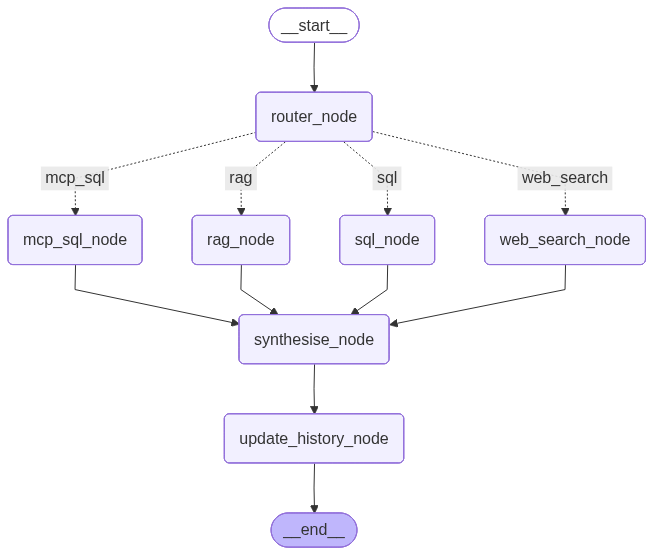

In [19]:
from agent.graph import build_graph

compiled_graph = build_graph()
compiled_graph

### Step 4 — 그래프 시각화

LangGraph의 내장 Mermaid 렌더러로 PNG를 만들어 노트북에 인라인 표시합니다. (파일로 저장하지는 않습니다.)

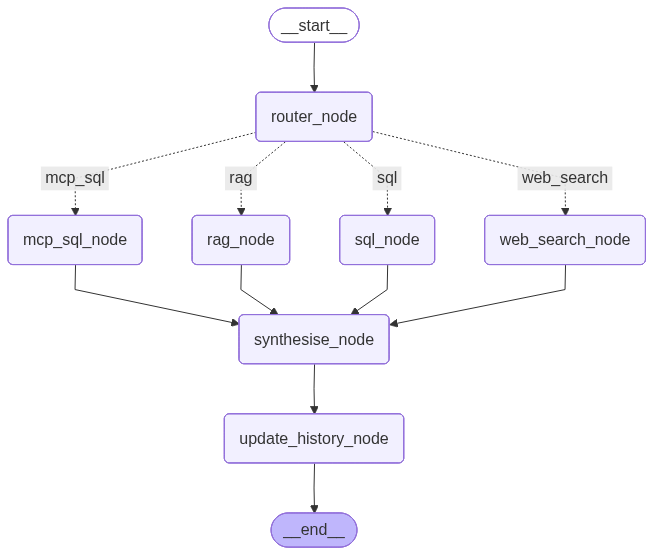

In [20]:
from IPython.display import Image, display

png_bytes = compiled_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

### Step 5 — Session 생성

`EcommerceSession`은 컴파일된 그래프 + 대화 이력 + 턴 카운터를 캡슐화합니다. 이후 단계에서는 `session.ask(...)` 만 호출하면 됩니다.

In [21]:
from session import EcommerceSession

session = EcommerceSession()
print("Session ID :", session.session_id)
print("Turn       :", session.turn_number)

Session ID : bea150be
Turn       : 0


### Step 6 — 데모 질의

라우터가 세 종류의 도구(SQL / Web Search / RAG)로 각각 분기하는지 한 셀씩 차례로 확인합니다.

#### 6-1. SQL 라우트 — 주문/판매 데이터 질의

In [22]:
answer = session.ask("성공적으로 배송된 주문은 몇 개인가요?")
print(answer)


[router] → SQL  |  배송 완료된 주문 수는 DB의 주문 테이블에서 집계할 수 있는 정형 데이터 질의입니다.
[sql_node] Generating and executing SQL …
[sql_node] SQL: SELECT COUNT(order_id) AS delivered_order_count
FROM orders
WHERE order_status = 'delivered';
[sql_node] 1 rows returned.
[synthesise_node] Answer ready (542 chars).
## 📦 성공적으로 배송 완료된 주문 현황

### 핵심 수치

| 항목 | 수치 |
|------|------|
| 배송 완료 주문 수 | **87,428건** |

---

### 📊 분석 요약

현재 데이터베이스 기준으로 **배송 완료(`delivered`) 상태의 주문은 총 87,428건**입니다.

- 이 수치는 고객에게 **실제로 상품이 전달된 주문**만을 집계한 결과입니다.
- 전체 주문 대비 배송 완료 비율을 파악하면 **주문 이행률(Fulfillment Rate)** 을 산출할 수 있으며, 물류 운영 효율성을 평가하는 핵심 지표로 활용됩니다.
- 배송 완료 건수가 높을수록 **고객 만족도 및 재구매율**에 긍정적인 영향을 미칩니다.

---

### 💡 추가 분석 제안

> 더 깊은 인사이트를 원하신다면 아래 분석을 추천드립니다.
> - **전체 주문 대비 배송 완료 비율** (취소·반품·배송 중 주문과 비교)
> - **기간별 배송 완료 추이** (월별/분기별 트렌드 분석)
> - **배송 완료까지 평균 소요 시간** (물류 효율성 평가)


#### 6-2. Web Search 라우트 — 외부 최신 정보

In [23]:
answer = session.ask("한국에서 최근(2026년) e-commerce 트렌드가 뭐야?")
print(answer)


[router] → WEB_SEARCH  |  한국의 2026년 최신 이커머스 트렌드는 실시간 외부 정보가 필요한 질문으로, DB나 PDF가 아닌 웹 검색이 적합합니다.
[web_node] Searching the web …
[web_node] 5 results for query: '성공적으로 배송된 주문은 몇 개인가요?
한국에서 최근(2026년) e-commerce 트렌드가 뭐야?'
[synthesise_node] Answer ready (1452 chars).
## 📦 성공적으로 배송 완료된 주문 현황

| 항목 | 수치 |
|------|------|
| 배송 완료 주문 수 | **87,428건** |

배송 완료(`delivered`) 상태의 주문만을 집계한 결과이며, 고객에게 실제로 상품이 전달된 건수입니다.

---

## 🛒 한국 2026년 e-Commerce 주요 트렌드

### 1. 🚀 쿠팡 독주에 대한 반격 구도 형성
- 쿠팡에 눌려 있던 **온·오프라인 리테일 기업들의 반격 여지**가 생기며, 2026년이 재도약의 '마지막 기회'로 평가됨
- 커머스 시장 내 경쟁 구도가 재편될 가능성 주목
- 📎 출처: [2026년 커머스 시장의 '마지막 기회'를 보여주는 8가지 문장](https://contents.premium.naver.com/connectx/us/contents/260109162654467yo)

---

### 2. ⚡ 초고속 배송 & 물류 통합
- **Ultra-fast delivery(당일·즉시 배송)** 및 물류 통합이 한국 e-commerce의 핵심 경쟁 요소로 부상
- 무료 배송, 명확한 배송 시간, 간편 반품은 이제 **기본 조건(Hygiene Factor)** 으로 자리잡음
- 📎 출처: [South Korea B2C Ecommerce Market Forecast Report 2025-2029](https://finance.yahoo.com/news/south-korea-b2c-ecommerce-market-11400

Trace(trace_id=tr-7986ea22bb28e6d6ff1a875c25335fc3)

#### 6-3. RAG 라우트 — 사내 PDF 문서 기반

In [24]:
answer = session.ask("가전제품 반품 정책에 대해서 알려줘.")
print(answer)


[router] → RAG  |  가전제품 반품 정책은 업로드된 문서(PDF 매뉴얼/정책서)에서 찾아야 하는 문서 기반 질문이므로 RAG를 선택합니다.
[rag_node] Retrieving document chunks …
[rag_node] 4 chunks retrieved from: ['shopbr_return_policy.pdf']
[synthesise_node] Answer ready (896 chars).
## 🏠 ShopBR 가전제품 반품 정책 안내

> 📄 출처: **shopbr_return_policy.pdf** (ShopBR E-Commerce | Return & Replacement Policy, Effective Date: January 1, 2024)

---

### 📋 카테고리별 반품 기간 요약

| 제품 카테고리 | 반품 가능 기간 | 비고 |
|---|---|---|
| **에어컨** | 7일 이내 | 미설치 상태, 무료 방문 수거 |
| **오븐 / 전자레인지** | 15일 이내 | 미사용 상태, 무료 방문 수거 |
| **매트리스** | 조건부 | 개봉·사용 시 반품 불가 (결함 클레임 제외) |

---

### ⚠️ 주요 유의사항

- **대형 가전 반품**은 반드시 **반품 기간 내에 ShopBR 포털을 통해 사전 예약**이 필요합니다.
- **매트리스**는 개봉 후 사용한 경우 반품이 **불가**하며, 제품 결함이 확인된 경우에만 예외적으로 반품 신청이 가능합니다.
- **전문 설치 서비스**(예: 에어컨 설치)는 반품 정책의 적용 범위에 **포함되지 않습니다.**
- 배송 시 존재하지 않았던 **물리적 손상, 오용, 임의 변경** 등이 확인된 제품은 반품 대상에서 **제외**됩니다.

---

### 📌 법적 근거

ShopBR의 모든 반품 정책은 **브라질 소비자보호법(CDC) — Law No. 8.078/1990** 을 준수하여 운영됩니다.

---

### 💡 추가 안내

문서에서 제공된 발췌 내용이 일부에 한정

Trace(trace_id=tr-4a34f498e4f2a2ae7fc98e83228389d9)

In [10]:
answer = session.ask("What does our return policy say about electronics?")
print(answer)


[router] → RAG  |  사용자가 업로드된 반품 정책 문서(PDF)에서 전자제품 관련 반품 정책 내용을 묻고 있으므로 RAG 도구를 사용해야 합니다.
[rag_node] Retrieving document chunks …
[rag_node] 4 chunks retrieved from: ['shopbr_return_policy.pdf']
[synthesise_node] Answer ready (996 chars).
## 🔌 가전제품(Electronics & Gadgets) 반품 정책

> 📄 출처: **shopbr_return_policy.pdf** (v3.2, 시행일: 2024년 1월 1일)

---

### 📌 핵심 요약

가전제품은 **복잡성과 높은 가치**를 고려하여 **강화된 품질 기준**이 적용되며, ShopBR은 **공인 서비스 센터**와 협력하여 정품 교체 및 전문 수리를 보장합니다.

---

### 📋 반품 가능 조건 (일반 기준 적용)

| 상황 | 반품 가능 | 교체 가능 | 환불 가능 |
|------|:---------:|:---------:|:---------:|
| 상품 설명과 다른 경우 | ✅ | ✅ | ✅ |
| 불량/배송 중 파손 | ✅ | ✅ | ✅ |
| 단순 변심 (미개봉) | ✅ | ❌ | 🔶 부분 환불 |
| 단순 변심 (개봉) | 카테고리별 상이 | ❌ | ❌ |
| 오배송 | ✅ | ✅ | ✅ |
| 구성품 누락 | ✅ | ✅ | ✅ |

---

### ⚠️ 반품 불가 조건

아래 경우에는 반품이 **불가**합니다:
- 🔧 **임의 개조(tampering)** 또는 **오사용(misuse)**
- 💥 **배송 후 발생한 물리적 파손**

---

### 📦 일반 반품 공통 조건

- 상품은 **원래 포장재 또는 동등한 보호 포장**으로 반송
- **모든 구성품, 설명서, 케이블, 태그** 포함 필수

---

### ℹ️ 참고

발췌된 문서에 가전제품의 **세부 반품/교체 기간(Return Window 

Trace(trace_id=tr-f1c7def1bd6e566201104c13d8d936fa)

In [25]:
session.get_history()

[{'role': 'user', 'content': '성공적으로 배송된 주문은 몇 개인가요?'},
 {'role': 'assistant',
  'content': '## 📦 성공적으로 배송 완료된 주문 현황\n\n### 핵심 수치\n\n| 항목 | 수치 |\n|------|------|\n| 배송 완료 주문 수 | **87,428건** |\n\n---\n\n### 📊 분석 요약\n\n현재 데이터베이스 기준으로 **배송 완료(`delivered`) 상태의 주문은 총 87,428건**입니다.\n\n- 이 수치는 고객에게 **실제로 상품이 전달된 주문**만을 집계한 결과입니다.\n- 전체 주문 대비 배송 완료 비율을 파악하면 **주문 이행률(Fulfillment Rate)** 을 산출할 수 있으며, 물류 운영 효율성을 평가하는 핵심 지표로 활용됩니다.\n- 배송 완료 건수가 높을수록 **고객 만족도 및 재구매율**에 긍정적인 영향을 미칩니다.\n\n---\n\n### 💡 추가 분석 제안\n\n> 더 깊은 인사이트를 원하신다면 아래 분석을 추천드립니다.\n> - **전체 주문 대비 배송 완료 비율** (취소·반품·배송 중 주문과 비교)\n> - **기간별 배송 완료 추이** (월별/분기별 트렌드 분석)\n> - **배송 완료까지 평균 소요 시간** (물류 효율성 평가)'},
 {'role': 'user', 'content': '한국에서 최근(2026년) e-commerce 트렌드가 뭐야?'},
 {'role': 'assistant',
  'content': "## 📦 성공적으로 배송 완료된 주문 현황\n\n| 항목 | 수치 |\n|------|------|\n| 배송 완료 주문 수 | **87,428건** |\n\n배송 완료(`delivered`) 상태의 주문만을 집계한 결과이며, 고객에게 실제로 상품이 전달된 건수입니다.\n\n---\n\n## 🛒 한국 2026년 e-Commerce 주요 트렌드\n\n### 1. 🚀 쿠팡 독주에 대한 반격 구도 형성\n- 쿠팡에 눌

### Step 7 — 내부 상태 관찰

`session.ask()`는 최종 답변만 반환하지만, 학습 목적으로 한 번은 `compiled_graph.invoke()`를 직접 호출해 `route` (선택된 도구), `route_reason` (라우터의 판단 근거), 그리고 해당 도구의 원시 결과까지 살펴봅니다.

이 셀은 별도 invoke 이므로 `session.conversation_history` 에는 누적되지 않습니다.

In [26]:
from agent.state import AgentState

initial_state: AgentState = {
    "user_message":         "Show me the top 5 product categories by total revenue.",
    "conversation_history": session.get_history(),
    "route":                "",
    "route_reason":         "",
    "sql_result":           None,
    "rag_result":           None,
    "web_search_result":    None,
    "final_answer":         "",
    "turn_number":          session.turn_number + 1,
}

final_state = compiled_graph.invoke(initial_state)

print("Route        :", final_state["route"])
print("Route reason :", final_state["route_reason"])

print("\n--- Tool result ---")
for key in ("sql_result", "rag_result", "web_search_result"):
    if final_state.get(key):
        print(f"[{key}]")
        print(final_state[key])

print("\n--- Final answer ---")
print(final_state["final_answer"])


[router] → SQL  |  사용자가 제품 카테고리별 총 매출 상위 5개를 요청하는 전형적인 DB 집계/분석 질의로, SQL 도구가 적합합니다.
[sql_node] Generating and executing SQL …
[sql_node] SQL: SELECT
    p.product_category_name,
    SUM(oi.price + oi.shipping_charges) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 5;
[sql_node] 5 rows returned.
[synthesise_node] Answer ready (1204 chars).
Route        : sql
Route reason : 사용자가 제품 카테고리별 총 매출 상위 5개를 요청하는 전형적인 DB 집계/분석 질의로, SQL 도구가 적합합니다.

--- Tool result ---
[sql_result]
{'sql': "SELECT\n    p.product_category_name,\n    SUM(oi.price + oi.shipping_charges) AS total_revenue\nFROM order_items oi\nJOIN products p ON oi.product_id = p.product_id\nJOIN orders o ON oi.order_id = o.order_id\nWHERE o.order_status = 'delivered'\nGROUP BY p.product_category_name\nORDER BY total_revenue DESC\nLIMIT 5;", 'rows': [{'prod

[Trace(trace_id=tr-561dc77070a66c9c57b8fae8d787cfbe), Trace(trace_id=tr-65f79ba224d6d4f7e39a8aec91ecb319), Trace(trace_id=tr-9267eb60e52b010ff32cd9c3ae06186b)]

### Step 8 — 자유 질의

아래 `question` 문자열만 바꿔서 같은 셀을 반복 실행하면 됩니다. 같은 `session` 객체를 사용하므로 이전 턴의 맥락이 유지됩니다.

In [27]:
# question = "여기에 질문을 입력하세요"

# answer = session.ask(question)
# print(answer)

### Step 9 — 대화 이력 확인 / 초기화

In [28]:
session.print_history()


════════════════════════════════════════════════════════════
  Session bea150be  |  3 turns
════════════════════════════════════════════════════════════

[User]
성공적으로 배송된 주문은 몇 개인가요?

[Assistant]
## 📦 성공적으로 배송 완료된 주문 현황

### 핵심 수치

| 항목 | 수치 |
|------|------|
| 배송 완료 주문 수 | **87,428건** |

---

### 📊 분석 요약

현재 데이터베이스 기준으로 **배송 완료(`delivered`) 상태의 주문은 총 87,428건**입니다.

- 이 수치는 고객에게 **실제로 상품이 전달된 주문**만을 집계한 결과입니다.
- 전체 주문 대비 배송 완료 비율을 파악하면 **주문 이행률(Fulfillment Rate)** 을 산출할 수 있으며, 물류 운영 효율성을 평가하는 핵심 지표로 활용됩니다.
- 배송 완료 건수가 높을수록 **고객 만족도 및 재구매율**에 긍정적인 영향을 미칩니다.

---

### 💡 추가 분석 제안

> 더 깊은 인사이트를 원하신다면 아래 분석을 추천드립니다.
> - **전체 주문 대비 배송 완료 비율** (취소·반품·배송 중 주문과 비교)
> - **기간별 배송 완료 추이** (월별/분기별 트렌드 분석)
> - **배송 완료까지 평균 소요 시간** (물류 효율성 평가)

[User]
한국에서 최근(2026년) e-commerce 트렌드가 뭐야?

[Assistant]
## 📦 성공적으로 배송 완료된 주문 현황

| 항목 | 수치 |
|------|------|
| 배송 완료 주문 수 | **87,428건** |

배송 완료(`delivered`) 상태의 주문만을 집계한 결과이며, 고객에게 실제로 상품이 전달된 건수입니다.

---

## 🛒 한국 2026년 e-Commerce 주요 트렌드

### 1. 🚀 쿠팡 독주에 대한 반

In [29]:
# 필요 시 실행 — 대화 이력을 모두 비웁니다.
session.reset()

[session:bea150be] Conversation reset.


In [30]:
session.print_history()


════════════════════════════════════════════════════════════
  Session bea150be  |  0 turns
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════

